In [ ]:
# Load a learnMSA2 model
# Load an alignment and embedding data
# Plot the aligned embeddings

In [8]:
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

import tensorflow as tf
import numpy as np

from learnMSA.util import AlignedDataset, EmbeddingDataset
from learnMSA.protein_language_models.compute_embeddings import compute_embeddings
from learnMSA.config import LanguageModelConfig

2026-06-08 11:42:48.062078: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780911768.078442 1296850 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780911768.083579 1296850 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780911768.096942 1296850 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780911768.096962 1296850 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780911768.096964 1296850 computation_placer.cc:177] computation placer alr

In [3]:
msa_file = "../../snakeMSA/outputs/learnMSA/learnMSA2_new/alignments/trfl.vie"
plm_config = LanguageModelConfig()

with AlignedDataset(msa_file) as data:
    # Remove gaps to compute embeddings
    data.remove_gaps = True

    emb = compute_embeddings(data, plm_config)

    emb_data = EmbeddingDataset(embedding_cache = emb, seq_ids = data.seq_ids)

    # Don't remove gaps anymore. Now get_standardized_seq returns
    # upper case amino acid sequences with gaps.
    data.remove_gaps = False
    data.get_standardized_seq(0)

/home/felix/miniforge3/envs/learnMSAdev2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-08 11:42:53.460348: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1780911773.461785 1296850 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22151 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_embedding(
    data: AlignedDataset, emb_data: EmbeddingDataset, i: int
) -> None:
    """
    Plot a heatmap of the embedding for sequence i in an alignment.

    Gap columns from the alignment are shown as white space. Non-gap
    positions are labeled with their amino acid character on the x axis.

    Args:
        data: AlignedDataset with the alignment (remove_gaps state is
            temporarily overridden to False to obtain the gapped sequence).
        emb_data: EmbeddingDataset with per-residue embeddings (no gaps).
        i: Index of the sequence to plot.
    """
    # Temporarily read gapped sequence
    prev_remove_gaps = data.remove_gaps
    data.remove_gaps = False
    seq = data.get_standardized_seq(i)
    data.remove_gaps = prev_remove_gaps

    gap_char = data.gap_symbols[0]

    # Embeddings cover only non-gap residues: shape (n_residues, emb_dim)
    emb = emb_data.get_encoded_seq(i)
    emb_dim = emb.shape[1]
    align_len = len(seq)

    # Build (emb_dim x align_len) matrix; gap columns remain NaN (white)
    heatmap = np.full((emb_dim, align_len), np.nan)
    residue_idx = 0
    for col_idx, aa in enumerate(seq):
        if aa != gap_char:
            heatmap[:, col_idx] = emb[residue_idx]
            residue_idx += 1

    fig, ax = plt.subplots(figsize=(max(10, align_len * 0.35), 5))
    sns.heatmap(
        heatmap,
        ax=ax,
        xticklabels=list(seq),
        mask=np.isnan(heatmap),
        cmap="viridis",
        cbar_kws={"label": "Embedding value"},
    )
    ax.set_xlabel("Alignment position")
    ax.set_ylabel("Embedding dimension")
    ax.set_title(data.seq_ids[i])
    plt.tight_layout()
    plt.show()


def plot_aligned_embeddings(
    data: AlignedDataset,
    emb_data: EmbeddingDataset,
    indices: list[int] | None = None
) -> None:
    """
    Plot heatmaps for multiple sequences row-wise in a single figure.

    Gap columns from the alignment are shown as white space; columns that
    are gaps in every plotted sequence are dropped entirely. Non-gap
    positions are labeled with their amino acid character on the x axis.

    Args:
        data: AlignedDataset with the alignment.
        emb_data: EmbeddingDataset with per-residue embeddings (no gaps).
        indices: List of sequence indices to plot. Defaults to all sequences.
    """
    prev_remove_gaps = data.remove_gaps
    data.remove_gaps = False

    if indices is None:
        indices = list(range(len(data.seq_ids)))

    seqs = [data.get_standardized_seq(i) for i in indices]
    gap_char = data.gap_symbols[0]

    data.remove_gaps = prev_remove_gaps

    align_len = len(seqs[0])
    emb_dim = emb_data.get_encoded_seq(indices[0]).shape[1]
    n = len(indices)

    # Identify columns that are gaps in every plotted sequence
    all_gap_cols = {
        col for col in range(align_len)
        if all(seq[col] == gap_char for seq in seqs)
    }
    keep_cols = [col for col in range(align_len) if col not in all_gap_cols]

    fig, axes = plt.subplots(
        n, 1,
        figsize=(max(10, len(keep_cols) * 0.35), 4 * n),
        squeeze=False,
    )

    for row, (i, seq) in enumerate(zip(indices, seqs)):
        emb = emb_data.get_encoded_seq(i)
        # Build full heatmap first, then select non-all-gap columns
        heatmap = np.full((emb_dim, align_len), np.nan)
        residue_idx = 0
        for col_idx, aa in enumerate(seq):
            if aa != gap_char:
                heatmap[:, col_idx] = emb[residue_idx]
                residue_idx += 1
        heatmap = heatmap[:, keep_cols]
        xlabels = [seq[col] for col in keep_cols]

        ax = axes[row, 0]
        sns.heatmap(
            heatmap,
            ax=ax,
            xticklabels=xlabels,
            mask=np.isnan(heatmap),
            cmap="viridis",
            cbar_kws={"label": "Embedding value"},
        )
        ax.set_xlabel("Alignment position")
        ax.set_ylabel("Embedding dimension")
        ax.set_title(data.seq_ids[i])

    plt.tight_layout()
    plt.show()


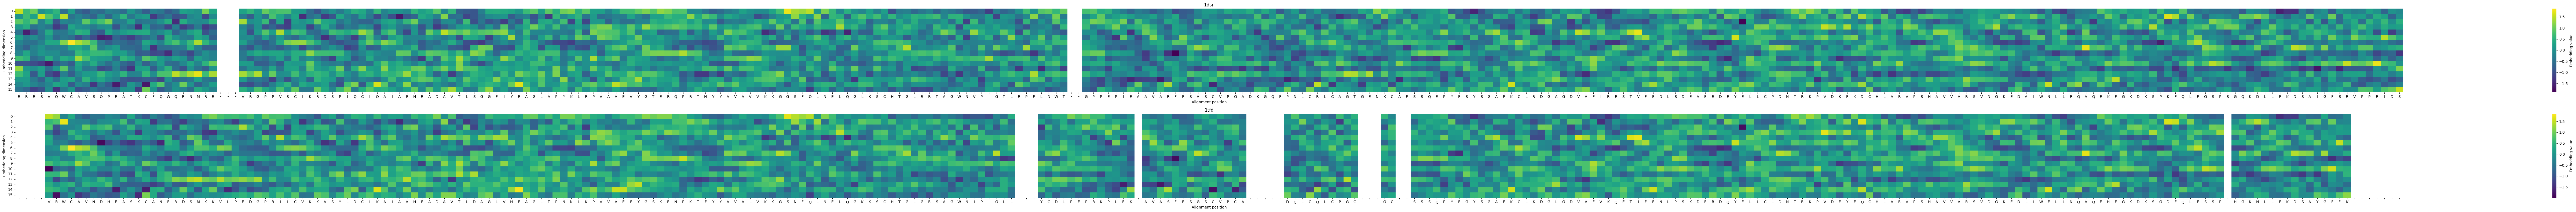

In [5]:
plot_aligned_embeddings(data, emb_data, [data.seq_ids.index("1dsn"), data.seq_ids.index("1tfd")])